In [1]:
from behave_analysis.process.session import get_experiment
from behave_analysis.utils.rayleigh.load_rayleigh import collect_all_rayleigh_paths, load_all_rayleigh_data
from behave_analysis.utils.rayleigh.manipulate_rayleigh_df import extract_compartment_values, extract_firing_rates
from collections import defaultdict
import matplotlib.pyplot as plt
from collections import Counter
import re
from settings.settings_analyze_efizz import Settings_ae
import numpy as np
import pandas as pd
import seaborn as sns

# Hard code data to load

In [2]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_7sept, JAL3_4sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may

In [3]:
# experiments_objects = [JAL3_7sept, JAL3_4sept, 
# JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
# JAL005_8thSept, JAL005_21stSept, 
# JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr,
# JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr, JAL7_30apr,
# JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may]

# JAL6
#experiments_objects = [JAL6_28mar, JAL6_flip5_25mar, JAL6_flip4_21mar, JAL6_flip7_1apr]

# JAL7
experiments_objects = [JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr]

# JAL8
#experiments_objects = [JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may]

# Regex to clean up .arrow file names

In [4]:
def regex(angle):
    "Remove unwanted characters from angle file string"
    pattern = r'^(.*?)(?=_Rayleigh)'
    match = re.search(pattern, angle)
    assert match, f"Could not find match for {angle}"
    return match.group(0)

# init parmas

In [5]:
# Init Params
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
total_cells = 0
total_sessions = 0
rayleigh_threshold = 0.15
fr_threshold = 5 # Hz

# Loop over sessions and count which angle / condition has the highest rayleigh vector

In [6]:
nested_across_session_ray_data = defaultdict(lambda: defaultdict(int)) # nested_across_session_ray_data[session][cell] = {max_shelter_rayleigh_name, max_threat_rayleigh_name, max_shelter_rayleigh, max_threat_rayleigh}
for i, session in enumerate(experiments_objects):
    
    loaded_session = get_experiment(session)
    paths = collect_all_rayleigh_paths(session = loaded_session, cluster_type = "good", conditions= conditions) # paths[condition][angles]
    condition_data = load_all_rayleigh_data(paths) # condition_data[condition][angles] ~ hdir, hsa, center, post flip, pre flip
    
    total_sessions += 1
    nCells = len(condition_data["shelter_only"]["hdir_Rayleigh.arrow"]["Rayleigh"]) # Cells are the same for all conditions and angles in one session
    total_cells += nCells
    
    for cell in range(nCells):

        rayleigh_shelter = 0
        rayleigh_threat = 0

        for ci, condition in enumerate(condition_data.keys()):
            for angle in condition_data[condition].keys():
                
                # Extract data
                output = extract_compartment_values(condition_data[condition][angle], column_name="Rayleigh")
                
                # Replace the largest rayleigh value if it is larger than the current one and save condition | angle combo for that cell
                if np.logical_and(output[cell][0] > rayleigh_shelter, output[cell][0] > rayleigh_threshold): # first element is shelter only
                    rayleigh_shelter = output[cell][0]
                    max_shelter_angle_str = regex(angle) + " | " + condition
                    
                if np.logical_and(output[cell][1] > rayleigh_threat, output[cell][1] > rayleigh_threshold): # second element is threat only
                    rayleigh_threat = output[cell][1]
                    max_threat_angle_str = regex(angle) + " | " + condition
        
        try:
            nested_across_session_ray_data[i][cell] = {"max_shelter_rayleigh_name": max_shelter_angle_str, 
                                    "max_threat_rayleigh_name": max_threat_angle_str,
                                    "max_shelter_rayleigh": rayleigh_shelter,
                                    "max_threat_rayleigh": rayleigh_threat}
        
        except:
            print(f"Cell {cell} in session {i} did not meet threshold")
            

Cell 0 in session 0 did not meet threshold
Cell 1 in session 0 did not meet threshold
Cell 2 in session 0 did not meet threshold


In [7]:
# A test to check the number of values matches the number of cells
# print(f"Total cells: {total_cells}")
# total = 0
# for i in nested_across_session_ray_data.keys():
#     total += len(nested_across_session_ray_data[i])
# assert total == total_cells, f"Total cells in nested dict {total} does not match total cells {total_cells}"
# print("total cells", total_cells)   


# Create lists and count how many times each element appears

In [8]:
big_list_shelter = []
big_list_threat = []
session_ids = []
for i, session in enumerate(nested_across_session_ray_data.keys()):
    for cell in nested_across_session_ray_data[i].keys():
        big_list_shelter.append(nested_across_session_ray_data[i][cell]["max_shelter_rayleigh_name"])
        big_list_threat.append(nested_across_session_ray_data[i][cell]["max_threat_rayleigh_name"])
    session_ids.append(i * np.ones(len(nested_across_session_ray_data[i].keys())))

# Counter object creates a dictionary where the keys are the unqiue elements and the values are the counts
shelter_counter = Counter(big_list_shelter)
threat_counter = Counter(big_list_threat)

# Make box plots across sessions for the rayleigh value

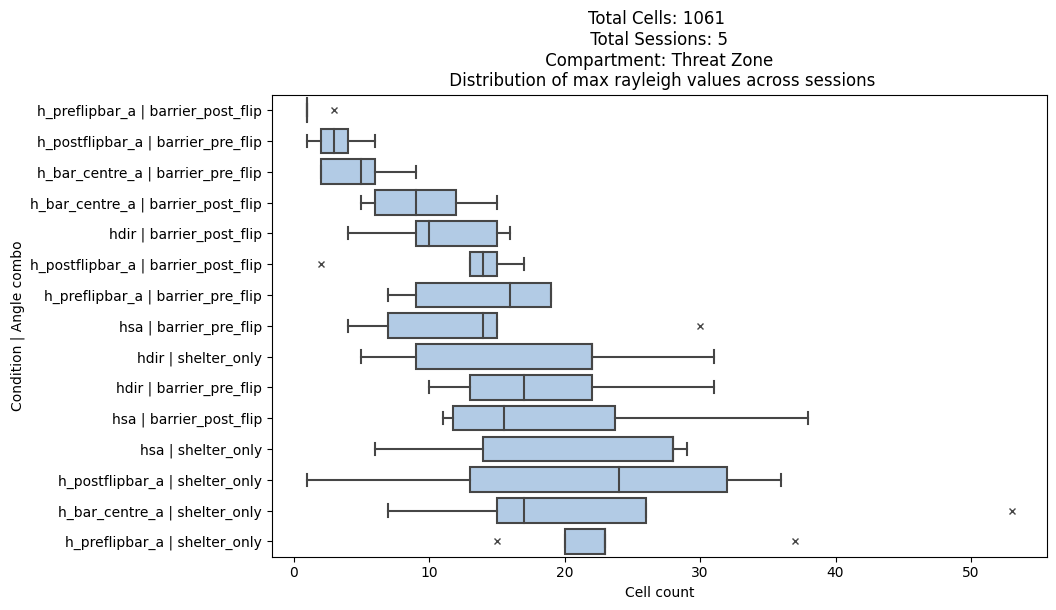

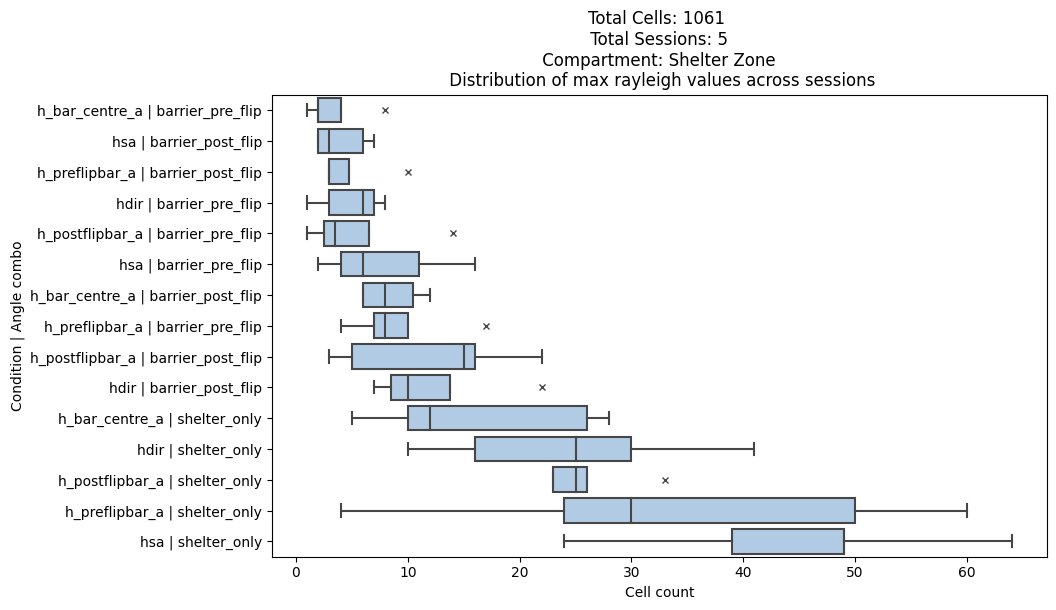

In [9]:

df = pd.DataFrame(big_list_threat, columns=['condition']) # each row is a condition | angle combo
df['session'] = np.concatenate(session_ids)
df['count'] = 1
group_df = df.groupby(['condition', 'session']).count().reset_index()
mean_counts = group_df.groupby('condition')['count'].mean().sort_values().index
plt.figure(figsize=(10, 6))
sns.boxplot(data=group_df, x='count', y='condition', orient='h', order=mean_counts, flierprops={"marker": "x"}, boxprops={"facecolor": (.4, .6, .8, .5)})
plt.ylabel('Condition | Angle combo')
plt.xlabel('Cell count')
plt.title(f'Total Cells: {total_cells} \n Total Sessions: {total_sessions} \n Compartment: Threat Zone \n Distribution of max rayleigh values across sessions')
plt.show()
#assert group_df['count'].sum() == total_cells, f"Total cells {total_cells} does not match sum of counts {group_df['count'].sum()}"

df = pd.DataFrame(big_list_shelter, columns=['condition']) # each row is a condition | angle combo
df['session'] = np.concatenate(session_ids)
df['count'] = 1
group_df = df.groupby(['condition', 'session']).count().reset_index()
mean_counts = group_df.groupby('condition')['count'].mean().sort_values().index
plt.figure(figsize=(10, 6))
sns.boxplot(data=group_df, x='count', y='condition', orient='h', order=mean_counts, flierprops={"marker": "x"}, boxprops={"facecolor": (.4, .6, .8, .5)})
plt.ylabel('Condition | Angle combo')
plt.xlabel('Cell count')
plt.title(f'Total Cells: {total_cells} \n Total Sessions: {total_sessions} \n Compartment: Shelter Zone \n Distribution of max rayleigh values across sessions')
plt.show()
##assert group_df['count'].sum() == total_cells, f"Total cells {total_cells} does not match sum of counts {group_df['count'].sum()}"



# Shelter compartment plot

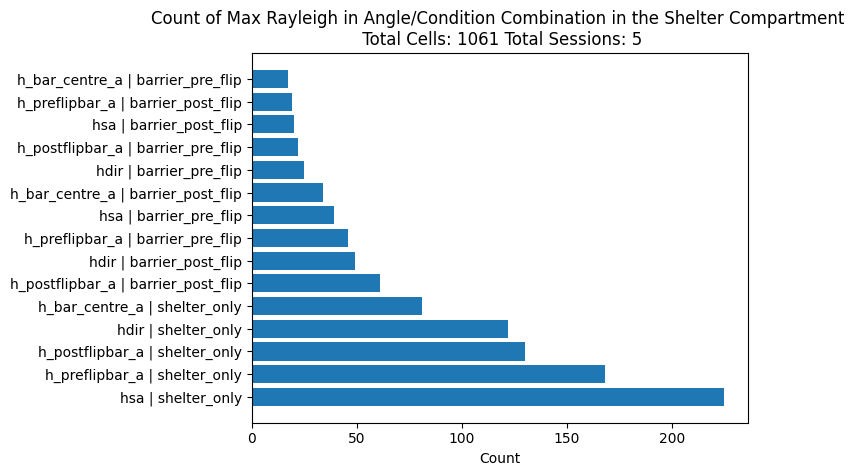

In [10]:
# Shelter compartment plot
shelter_elements = list(shelter_counter.keys())
shelter_counts = list(shelter_counter.values())

# Sort the shelter data by counts in descending order
sorted_indices_shelter = sorted(range(len(shelter_counts)), key=lambda i: shelter_counts[i], reverse=True)
sorted_elements_shelter = [shelter_elements[i] for i in sorted_indices_shelter]
sorted_counts_shelter = [shelter_counts[i] for i in sorted_indices_shelter]

# Plot for shelter
plt.barh(sorted_elements_shelter, sorted_counts_shelter)
plt.xlabel('Count')
plt.yticks(rotation=0)
plt.title(f'Count of Max Rayleigh in Angle/Condition Combination in the Shelter Compartment \n Total Cells: {total_cells} Total Sessions: {total_sessions}')
plt.show()

# Threat zone compartmnet plot

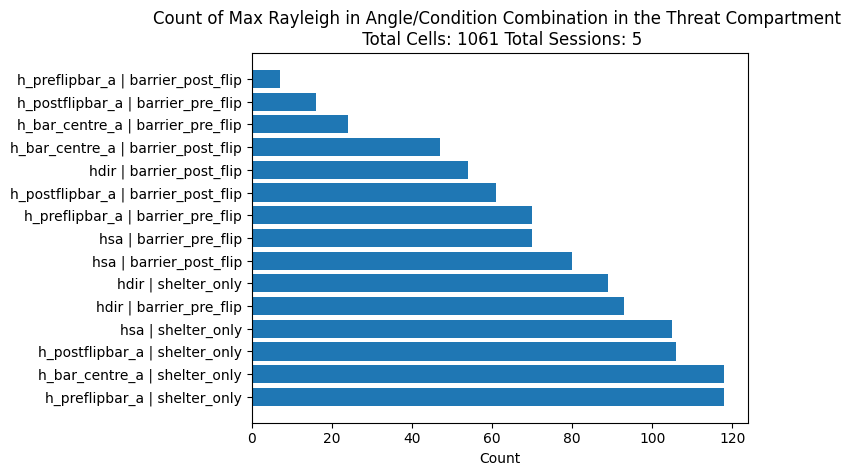

In [11]:
# Shelter compartment plot
threat_elements = list(threat_counter.keys())
threat_counts = list(threat_counter.values())

# Sort the shelter data by counts in descending order
sorted_indices_threat = sorted(range(len(threat_counts)), key=lambda i: threat_counts[i], reverse=True)
sorted_elements_threats = [threat_elements[i] for i in sorted_indices_threat]
sorted_counts_threat = [threat_counts[i] for i in sorted_indices_threat]

# Plot for shelter
plt.barh(sorted_elements_threats, sorted_counts_threat)
plt.xlabel('Count')
plt.yticks(rotation=0)
plt.title(f'Count of Max Rayleigh in Angle/Condition Combination in the Threat Compartment \n Total Cells: {total_cells} Total Sessions: {total_sessions}')
plt.show()

# Now plot the actual rayleigh values across conditions

In [12]:

threat_by_condition_values = {}
shelter_by_condition_values = {}

for i, session in enumerate(nested_across_session_ray_data.keys()):
    for cell in nested_across_session_ray_data[i].keys():        
        condition_name_shelter = nested_across_session_ray_data[i][cell]["max_shelter_rayleigh_name"]
        condition_name_threat = nested_across_session_ray_data[i][cell]["max_threat_rayleigh_name"]
        
        # make it into a list so I can append to it
        if condition_name_shelter not in shelter_by_condition_values.keys():
            shelter_by_condition_values[condition_name_shelter] = []
        if condition_name_threat not in threat_by_condition_values.keys():
            threat_by_condition_values[condition_name_threat] = []
            
        threat_by_condition_values[condition_name_threat].append(nested_across_session_ray_data[i][cell]["max_threat_rayleigh"])
        shelter_by_condition_values[condition_name_shelter].append(nested_across_session_ray_data[i][cell]["max_shelter_rayleigh"])
        

# Just plot threat zone values

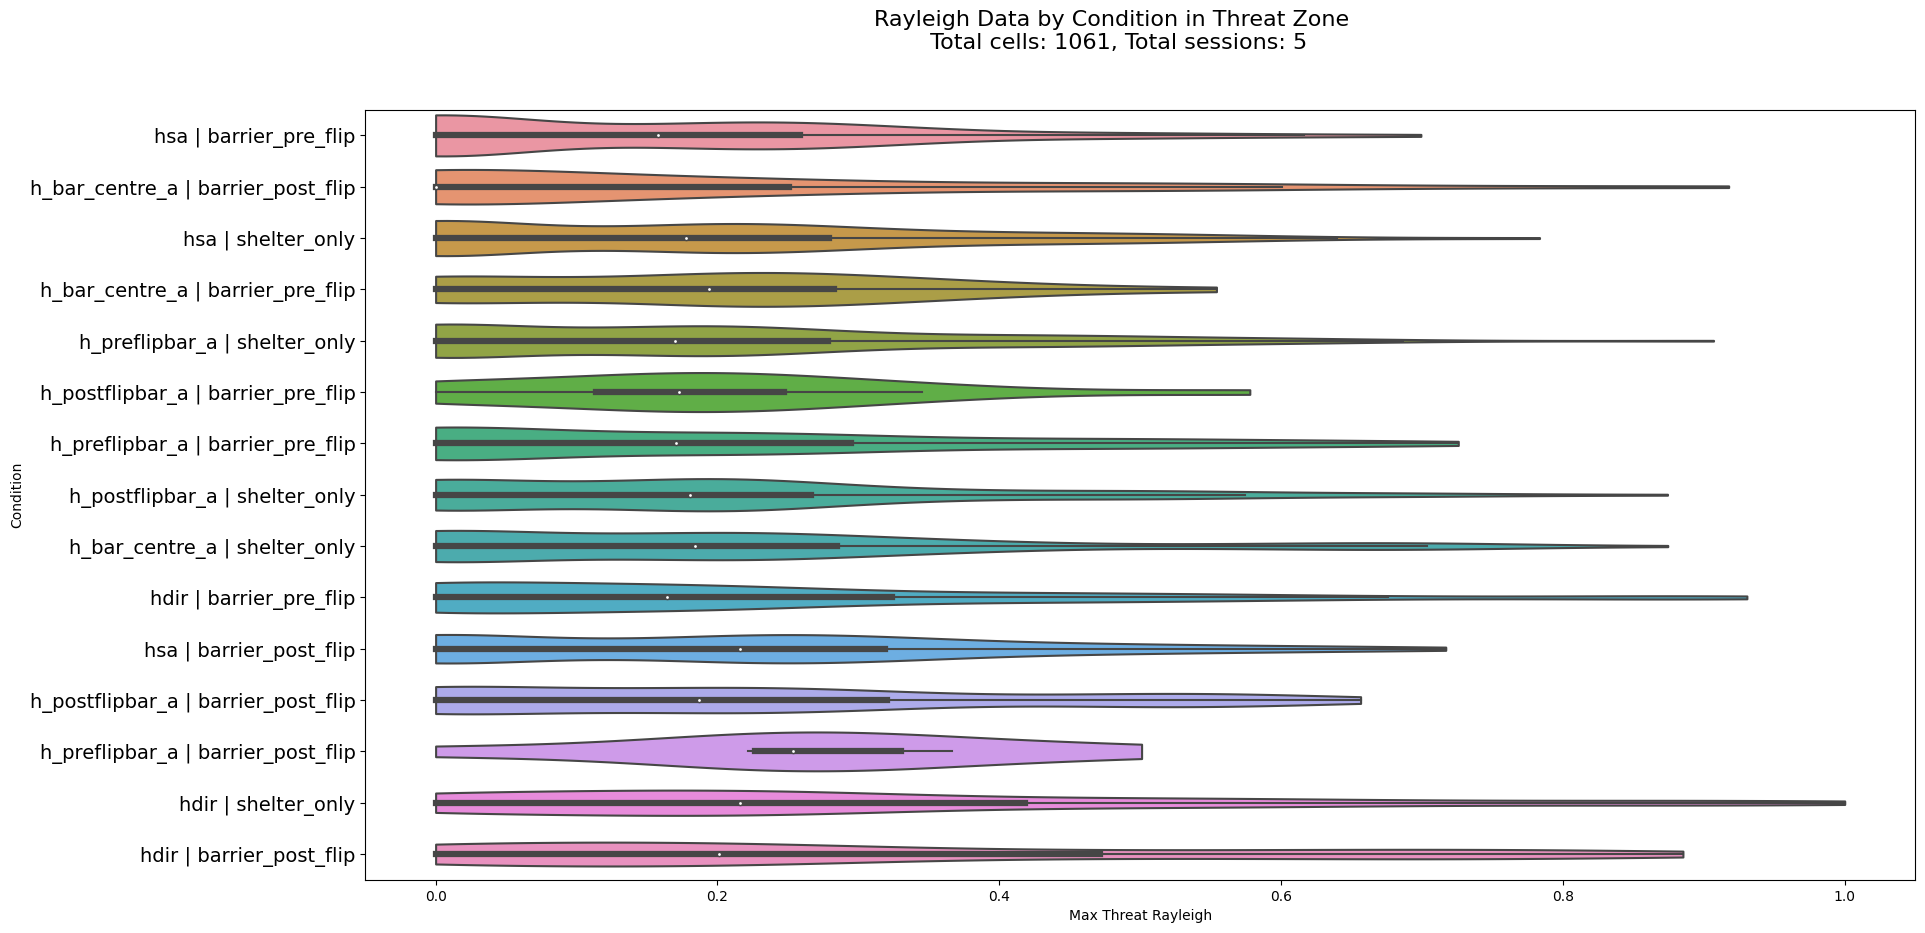

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert the threat data into a suitable DataFrame
threat_data = []
for condition, values in threat_by_condition_values.items():
    for value in values:
        threat_data.append({'Condition': condition, 'Value': value})
df_threat = pd.DataFrame(threat_data)

# Calculate mean of 'Value' for each 'Condition' and sort them
means = df_threat.groupby('Condition')['Value'].mean().sort_values(ascending=True)
ordered_conditions = means.index.tolist()

# Plotting setup
fig, ax = plt.subplots(figsize=(20, 10))

# Plot Threat Data with ordered conditions
sns.violinplot(x='Value', y='Condition', data=df_threat, order=ordered_conditions, ax=ax, cut=0)
ax.set_xlabel('Max Threat Rayleigh')
ax.set_ylabel('Condition')

# make y lavels font larger
plt.yticks(fontsize=14)

# Title and display
fig.suptitle(f'Rayleigh Data by Condition in Threat Zone \n Total cells: {total_cells}, Total sessions: {total_sessions}', fontsize=16)
plt.show()



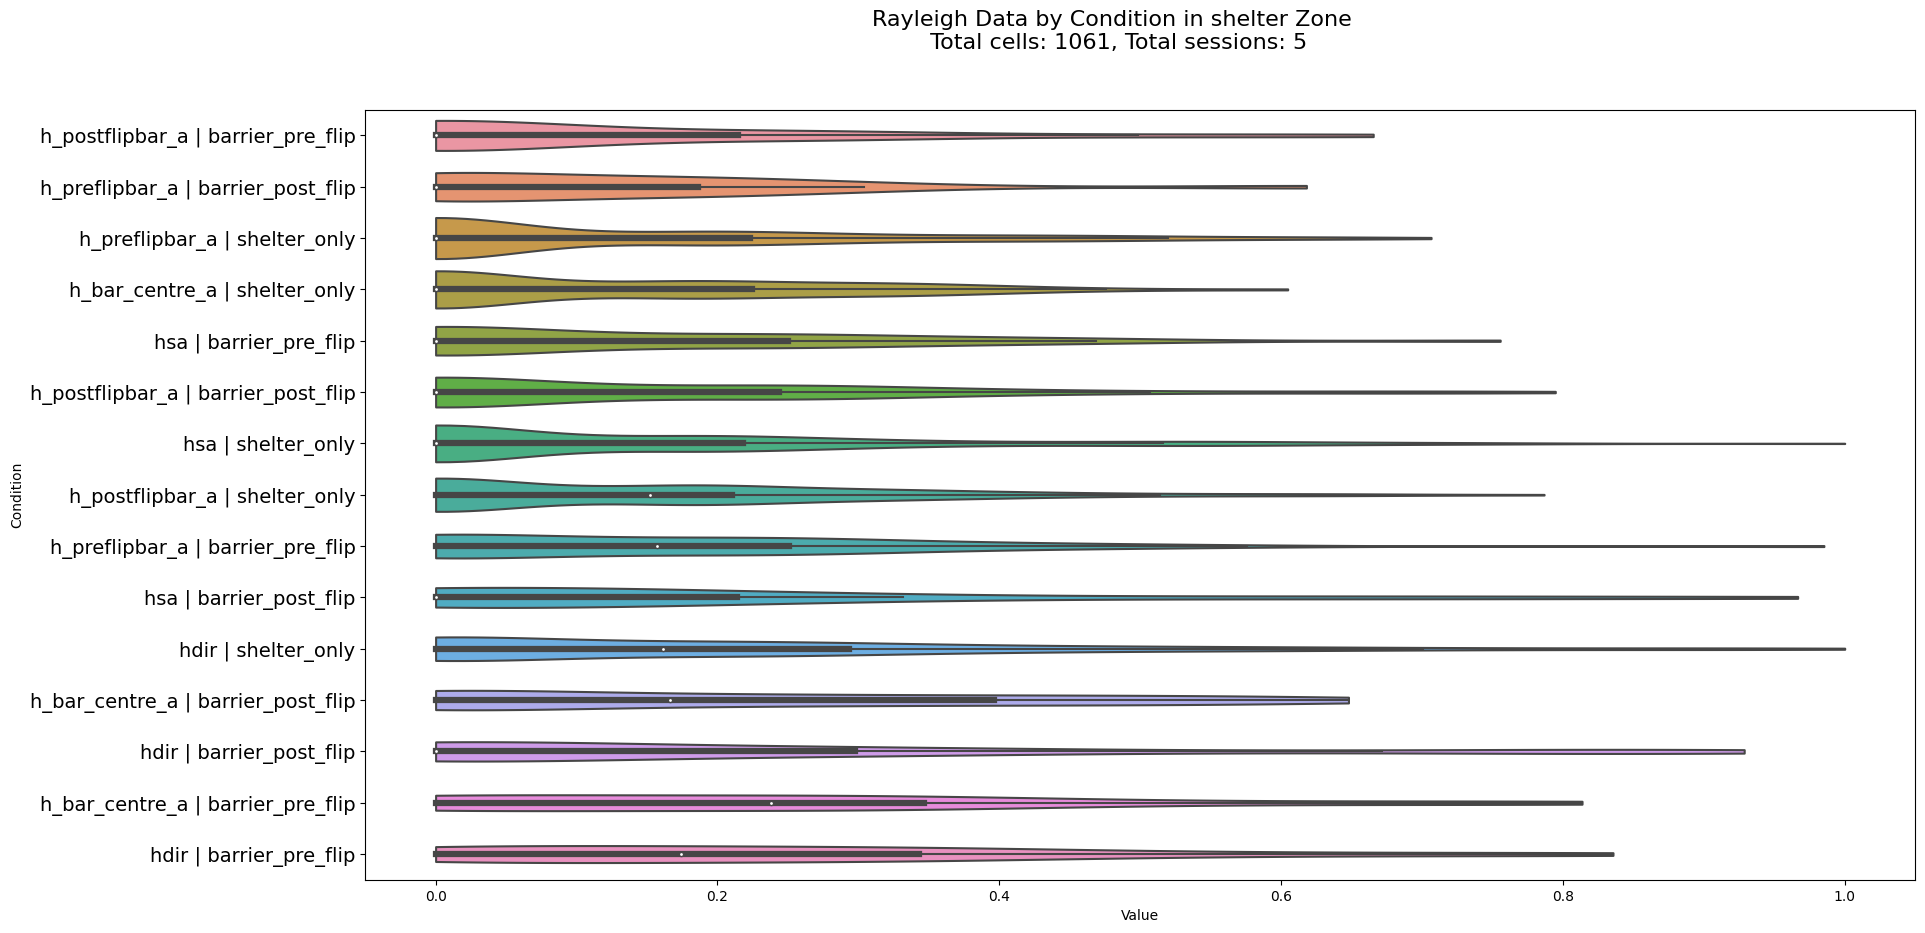

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert the threat data into a suitable DataFrame
shelter_data = []
for condition, values in shelter_by_condition_values.items():
    for value in values:
        shelter_data.append({'Condition': condition, 'Value': value})
df_shelter = pd.DataFrame(shelter_data)

# Calculate mean of 'Value' for each 'Condition' and sort them
means = df_shelter.groupby('Condition')['Value'].mean().sort_values(ascending=True)
ordered_conditions = means.index.tolist()

# Plotting setup
fig, ax = plt.subplots(figsize=(20, 10))

# Plot Threat Data with ordered conditions
sns.violinplot(x='Value', y='Condition', data=df_shelter, order=ordered_conditions, ax=ax, cut=0)
ax.set_ylabel('Condition')

# make y lavels font larger
plt.yticks(fontsize=14)

# Title and display
fig.suptitle(f'Rayleigh Data by Condition in shelter Zone \n Total cells: {total_cells}, Total sessions: {total_sessions}', fontsize=16)
plt.show()

# Loop over and see which one has the highest firing rate 

In [15]:
nested_across_session_fr_data = defaultdict(lambda: defaultdict(int)) # nested_across_session_fr_data[session][cell] = {max_shelter_rayleigh_name, max_threat_rayleigh_name, max_shelter_rayleigh, max_threat_rayleigh}
for i, session in enumerate(experiments_objects):
    loaded_session = get_experiment(session)
    paths = collect_all_rayleigh_paths(session = loaded_session, cluster_type = "good", conditions= conditions) # paths[condition][angles]
    condition_data = load_all_rayleigh_data(paths) # condition_data[condition][angles] ~ hdir, hsa, center, post flip, pre flip
    nCells = len(condition_data["shelter_only"]["hdir_Rayleigh.arrow"]["Rayleigh"]) # Cells are the same for all conditions and angles in one session
    for cell in range(nCells):
        
        max_fr_shelter = 0 
        max_fr_threat = 0
        
        for ci, condition in enumerate(condition_data.keys()):
            for angle in condition_data[condition].keys():
                
                # Extract data
                s_fr, t_fr = extract_firing_rates(condition_data[condition][angle], analyze_efizz_settings=Settings_ae)
                
                # Replace the largest fr value if it is larger than the current one and save condition | angle combo for that cell
                if np.logical_and(max(s_fr[cell]) > max_fr_shelter, max(s_fr[cell]) > fr_threshold): # first element is shelter only
                    max_fr_shelter = max(s_fr[cell])
                    max_fr_shelter_str = regex(angle) + " | " + condition
                    
                if np.logical_and(max(t_fr[cell]) > max_fr_threat, max(t_fr[cell]) > fr_threshold): # second element is threat only
                    max_fr_threat = max(t_fr[cell])
                    max_fr_threat_str = regex(angle) + " | " + condition
                    
        nested_across_session_fr_data[i][cell] = {"max_shelter_fr_name": max_fr_shelter_str, 
                                "max_threat_fr_name": max_fr_threat_str,
                                "max_shelter_fr": max_fr_shelter,
                                "max_threat_fr": max_fr_threat}    

# Create lists and count how many times each element appears

In [16]:
session_ids = []
big_list_shelter = []
big_list_threat = []
for i, session in enumerate(nested_across_session_fr_data.keys()):
    for cell in nested_across_session_fr_data[i].keys():
        big_list_shelter.append(nested_across_session_fr_data[i][cell]["max_shelter_fr_name"])
        big_list_threat.append(nested_across_session_fr_data[i][cell]["max_threat_fr_name"])
    session_ids.append(i * np.ones(len(nested_across_session_fr_data[i].keys())))


# Counter object creates a dictionary where the keys are the unqiue elements and the values are the counts
shelter_counter = Counter(big_list_shelter)
threat_counter = Counter(big_list_threat)

# plot shelter comparment firing rates

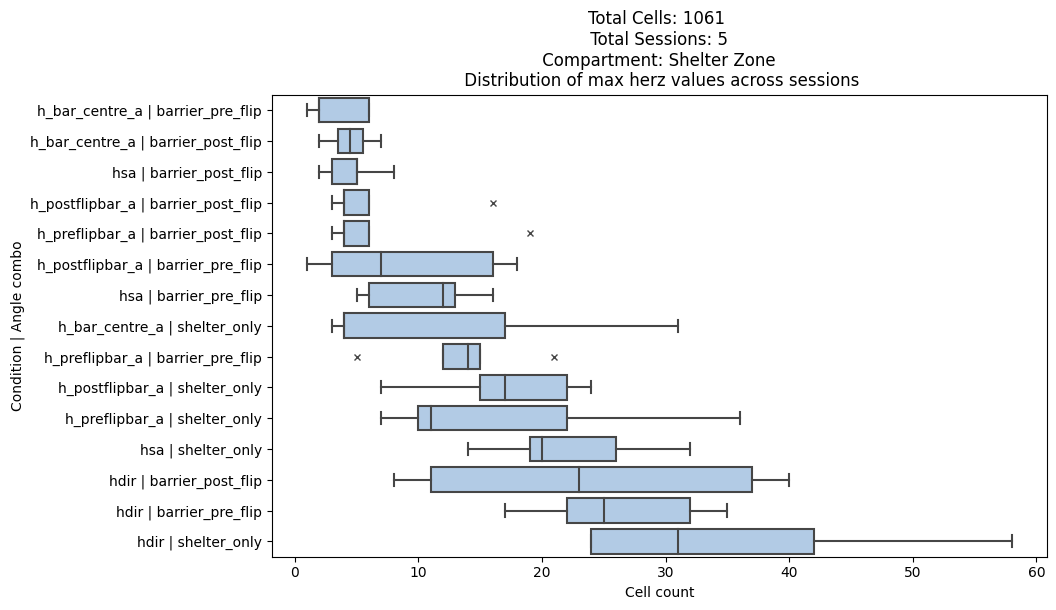

In [17]:
df = pd.DataFrame(big_list_shelter, columns=['condition']) # each row is a condition | angle combo
df['session'] = np.concatenate(session_ids)
df['count'] = 1
group_df = df.groupby(['condition', 'session']).count().reset_index()
mean_counts = group_df.groupby('condition')['count'].mean().sort_values().index
plt.figure(figsize=(10, 6))
sns.boxplot(data=group_df, x='count', y='condition', orient='h', order=mean_counts, flierprops={"marker": "x"}, boxprops={"facecolor": (.4, .6, .8, .5)})
plt.ylabel('Condition | Angle combo')
plt.xlabel('Cell count')
plt.title(f'Total Cells: {total_cells} \n Total Sessions: {total_sessions} \n Compartment: Shelter Zone \n Distribution of max herz values across sessions')
plt.show()

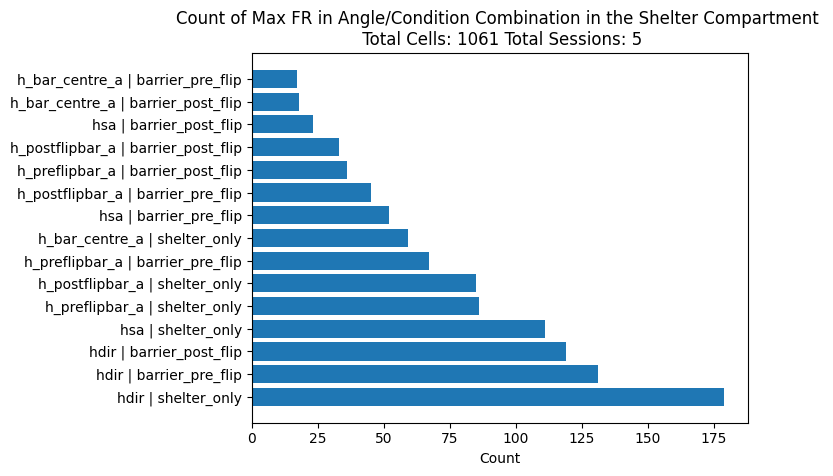

In [18]:
# Shelter compartment plot
shelter_elements = list(shelter_counter.keys())
shelter_counts = list(shelter_counter.values())

# Sort the shelter data by counts in descending order
sorted_indices_shelter = sorted(range(len(shelter_counts)), key=lambda i: shelter_counts[i], reverse=True)
sorted_elements_shelter = [shelter_elements[i] for i in sorted_indices_shelter]
sorted_counts_shelter = [shelter_counts[i] for i in sorted_indices_shelter]

# Plot for shelter
plt.barh(sorted_elements_shelter, sorted_counts_shelter)
plt.xlabel('Count')
plt.yticks(rotation=0)
plt.title(f'Count of Max FR in Angle/Condition Combination in the Shelter Compartment \n Total Cells: {total_cells} Total Sessions: {total_sessions}')
plt.show()

# Plot threat zone compartment firing rates

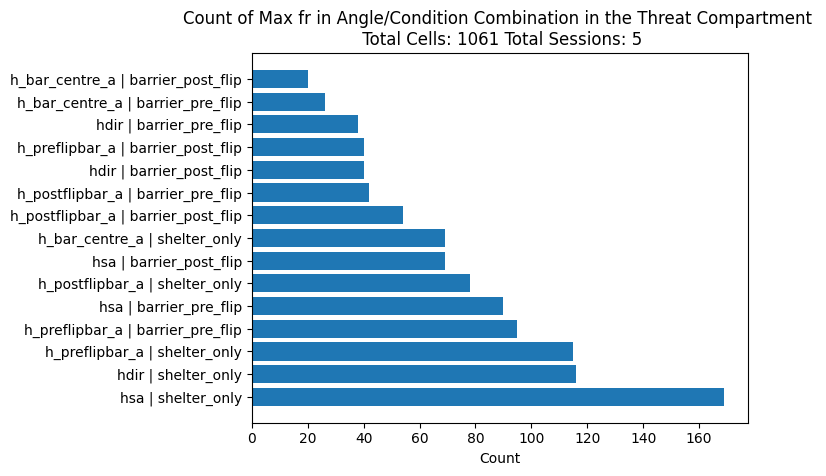

In [19]:
# Shelter compartment plot
threat_elements = list(threat_counter.keys())
threat_counts = list(threat_counter.values())

# Sort the shelter data by counts in descending order
sorted_indices_threat = sorted(range(len(threat_counts)), key=lambda i: threat_counts[i], reverse=True)
sorted_elements_threats = [threat_elements[i] for i in sorted_indices_threat]
sorted_counts_threat = [threat_counts[i] for i in sorted_indices_threat]

# Plot for shelter
plt.barh(sorted_elements_threats, sorted_counts_threat)
plt.xlabel('Count')
plt.yticks(rotation=0)
plt.title(f'Count of Max fr in Angle/Condition Combination in the Threat Compartment \n Total Cells: {total_cells} Total Sessions: {total_sessions}')
plt.show()

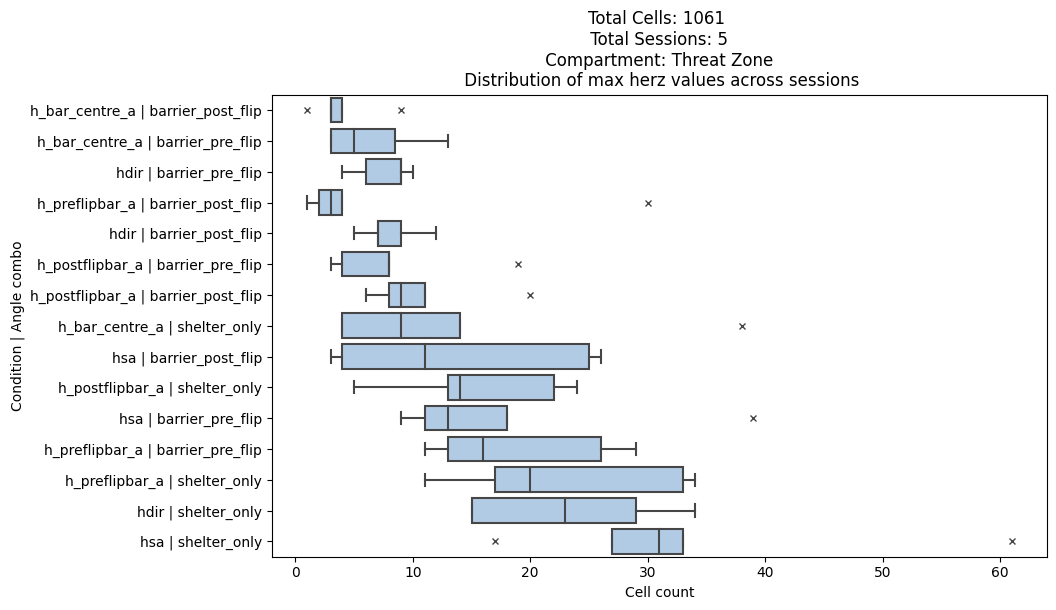

In [20]:
df = pd.DataFrame(big_list_threat, columns=['condition']) # each row is a condition | angle combo
df['session'] = np.concatenate(session_ids)
df['count'] = 1
group_df = df.groupby(['condition', 'session']).count().reset_index()
mean_counts = group_df.groupby('condition')['count'].mean().sort_values().index
plt.figure(figsize=(10, 6))
sns.boxplot(data=group_df, x='count', y='condition', orient='h', order=mean_counts, flierprops={"marker": "x"}, boxprops={"facecolor": (.4, .6, .8, .5)})
plt.ylabel('Condition | Angle combo')
plt.xlabel('Cell count')
plt.title(f'Total Cells: {total_cells} \n Total Sessions: {total_sessions} \n Compartment: Threat Zone \n Distribution of max herz values across sessions')
plt.show()

# Count subgoal putative cells and store cell IDs

In [21]:
condition_data["shelter_only"].keys()

dict_keys(['hdir_Rayleigh.arrow', 'hsa_Rayleigh.arrow', 'h_bar_centre_a_Rayleigh.arrow', 'h_postflipbar_a_Rayleigh.arrow', 'h_preflipbar_a_Rayleigh.arrow'])

In [22]:
nested_subgoal_data = defaultdict(int) # nested_across_session_fr_data[session][cell_type] = {max_shelter_rayleigh_name, max_threat_rayleigh_name, max_shelter_rayleigh, max_threat_rayleigh}
for i, session in enumerate(experiments_objects):
    loaded_session = get_experiment(session)
    paths = collect_all_rayleigh_paths(session = loaded_session, cluster_type = "good", conditions= conditions) # paths[condition][angles]
    condition_data = load_all_rayleigh_data(paths) # condition_data[condition][angles] ~ hdir, hsa, center, post flip, pre flip
    nCells = len(condition_data["shelter_only"]["hdir_Rayleigh.arrow"]["Rayleigh"]) # Cells are the same for all conditions and angles in one session
    num_pre_fli_shelter_subgoal_cells = 0
    num_pre_flip_threat_subgoal_cells = 0
    num_pre_fli_shelter_subgoal_cells_ids_list = []
    num_pre_flip_threat_subgoal_cells_ids_list = []
    
    for cell in range(nCells):
        rayleigh_shelter = 0
        rayleigh_threat = 0
        for ci, condition in enumerate(condition_data.keys()):
            for angle in condition_data[condition].keys():
                output = extract_compartment_values(condition_data[condition][angle], column_name="Rayleigh")
                    
                # Replace the largest rayleigh value if it is larger than the current one and save condition | angle combo for that cell
                if np.logical_and(output[cell][0] > rayleigh_shelter, output[cell][0] > rayleigh_threshold): # first element is shelter only
                    rayleigh_shelter = output[cell][0]
                    max_shelter_angle_str = regex(angle) + " | " + condition
                    max_shelter_angle_cell_id = condition_data[condition][angle][cell]["clusterID"][0]
                    
                if np.logical_and(output[cell][1] > rayleigh_threat, output[cell][1] > rayleigh_threshold): # second element is threat only
                    rayleigh_threat = output[cell][1]
                    max_threat_angle_str = regex(angle) + " | " + condition
                    max_threat_angle_cell_id = condition_data[condition][angle][cell]["clusterID"][0]  
                
                # Compare shelter condition and barreir firing increase
                if np.logical_and(condition == "shelter_only", angle == "h_preflipbar_a_Rayleigh.arrow"):
                    s_fr, t_fr = extract_firing_rates(condition_data[condition][angle], analyze_efizz_settings=Settings_ae)
                    shelter_condition_shel_compartment_fr_mean_pre_flip = np.mean(s_fr[cell])
                    shelter_condition_threat_compartment_fr_mean_pre_flip = np.mean(t_fr[cell])
                
                if np.logical_and(condition == "barrier_pre_flip", angle == "h_preflipbar_a_Rayleigh.arrow"):
                    s_fr, t_fr = extract_firing_rates(condition_data[condition][angle], analyze_efizz_settings=Settings_ae)
                    barrier_condition_shel_compartment_fr_mean_pre_flip = np.mean(s_fr[cell])
                    barrier_condition_threat_compartment_fr_mean_pre_flip = np.mean(t_fr[cell])
        
        # If the cell increases its firing rate between shelter compartment and barrier compartment for the pre flip AND the max raleigh value is the preflip angle in the preflip barrier condition
        if np.logical_and(shelter_condition_shel_compartment_fr_mean_pre_flip * 1.5 < barrier_condition_shel_compartment_fr_mean_pre_flip, 
                          max_shelter_angle_str == "h_preflipbar_a | barrier_pre_flip"):
            num_pre_fli_shelter_subgoal_cells += 1
            num_pre_fli_shelter_subgoal_cells_ids_list.append(max_shelter_angle_cell_id)
        
        if np.logical_and(shelter_condition_threat_compartment_fr_mean_pre_flip * 1.5 < barrier_condition_threat_compartment_fr_mean_pre_flip, 
                          max_threat_angle_str == "h_preflipbar_a | barrier_pre_flip"):
            num_pre_flip_threat_subgoal_cells += 1
            num_pre_flip_threat_subgoal_cells_ids_list.append(max_threat_angle_cell_id)
        
    nested_subgoal_data[i] = {"num_pre_flip_shelter_subgoal_cells": num_pre_fli_shelter_subgoal_cells,
                              "num_pre_flip_threat_subgoal_cells": num_pre_flip_threat_subgoal_cells,
                              "num_pre_fli_shelter_subgoal_cells_ids_list": num_pre_fli_shelter_subgoal_cells_ids_list,
                              "num_pre_flip_threat_subgoal_cells_ids_list": num_pre_flip_threat_subgoal_cells_ids_list}
    

In [23]:
for i in nested_subgoal_data.keys():
    print(f"The cell ids for threat zone pre flip is {nested_subgoal_data[i]['num_pre_flip_threat_subgoal_cells_ids_list']}")
    print(f"The cell ids for shelter zone pre flip is {nested_subgoal_data[i]['num_pre_fli_shelter_subgoal_cells_ids_list']}")
    
    print(f"Session {i} has {nested_subgoal_data[i]['num_pre_flip_shelter_subgoal_cells']} cells that increase firing rate in the shelter compartment between pre flip and barrier compartment")
    print(f"Session {i} has {nested_subgoal_data[i]['num_pre_flip_threat_subgoal_cells']} cells that increase firing rate in the threat compartment between pre flip and barrier compartment")
    print("\n")
nested_subgoal_data[0]["num_pre_flip_threat_subgoal_cells"]


The cell ids for threat zone pre flip is [557.0]
The cell ids for shelter zone pre flip is [458.0, 551.0]
Session 0 has 2 cells that increase firing rate in the shelter compartment between pre flip and barrier compartment
Session 0 has 1 cells that increase firing rate in the threat compartment between pre flip and barrier compartment


The cell ids for threat zone pre flip is [437.0, 515.0]
The cell ids for shelter zone pre flip is []
Session 1 has 0 cells that increase firing rate in the shelter compartment between pre flip and barrier compartment
Session 1 has 2 cells that increase firing rate in the threat compartment between pre flip and barrier compartment


The cell ids for threat zone pre flip is [393.0, 431.0, 643.0]
The cell ids for shelter zone pre flip is [344.0]
Session 2 has 1 cells that increase firing rate in the shelter compartment between pre flip and barrier compartment
Session 2 has 3 cells that increase firing rate in the threat compartment between pre flip and bar

1